# Capstone Assignment - Module I: Predicting some scientific data

**Objective:** Apply machine learning workflows to real scientific  data. You will preprocess data, justify model selection, perform cross-validation, and compare linear models against neural networks.

**Files provided:**
1. `student_data.csv`: Contains the physical features and the target variable (`cfinal`).
2. `evaluation_features.csv`: Contains physical features. The target variable is hidden. You will predict the `cfinal` for these materials and submit them. This will be tested against the expected ones and your score will depend on this.

---
## TEAM MEMBERS
Put here the lastnames, names and emails of your team members. 


---
# Part 1: Data Loading & Preprocessing
1. Load `student_data.csv`.
2. Perform basic Exploratory Data Analysis (EDA). Plot the distribution of `critical_temp`.
3. Check for missing values or extreme anomalies. Be very careful: remove data or if you impute it, justify strongly. 
5. Split this training data into your own local train/test sets (e.g., 80/20) so you can evaluate your models.
6. **Feature Scaling:** Apply appropriate scaling. *Hint: Think carefully about why scaling is absolutely strictly necessary for both Regularized Linear Models and Neural Networks.*

the size of the dataset is: 1462860
amount of columns: 86
amount of null values in the dataset: 1288
columns with null values: Index(['eon', 'amm', 'mwma', 'amg', 'wagm', 'mea', 'maew', 'mra', 'ramw',
       'sam', 'wsam', 'mf', 'mwf', 'fg', 'wgf', 'fe', 'wef', 'rf', 'rfw', 'sf',
       'swf', 'ram', 'rwam', 'gar', 'agwr', 'are', 'wear', 'arr', 'rraw',
       'sra', 'rwas', 'mD', 'mwD', 'Dg', 'wgD', 'De', 'Dew', 'rD', 'rDw', 'Ds',
       'Dws', 'mE', 'mEw', 'gE', 'gEw', 'Ee', 'weE', 'rE', 'Erw', 'sE', 'sEw',
       'mF', 'mwF', 'gF', 'gwF', 'eF', 'wFe', 'rF', 'rwF', 'sF', 'Fws', 'mT',
       'Twm', 'Tg', 'wgT', 'Te', 'eTw', 'rT', 'wrT', 'Ts', 'Tsw', 'Vm', 'mVw',
       'gV', 'gwV', 'eV', 'eVw', 'Vr', 'rwV', 'Vs', 'wVs', 'msqv', 'ril',
       'ped', 'deu', 'cfinal'],
      dtype='object')
null values per column:
eon       14
amm       10
mwma      12
amg       14
wagm      17
          ..
msqv      18
ril       18
ped       12
deu        8
cfinal    17
Length: 86, dtype: int64


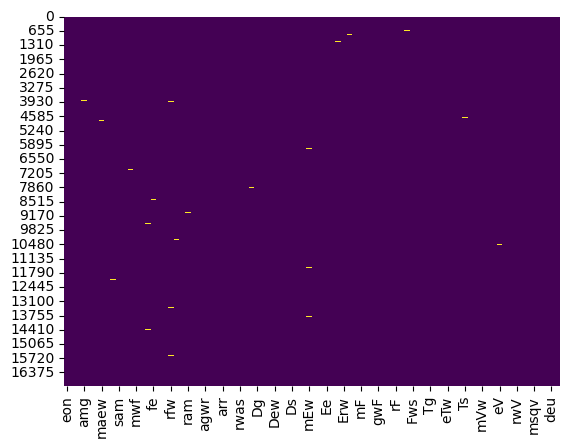


--- Statistical Summary of Ds ---

Skewness: 0.8600716765048626
Kurtosis: 2.20364527480232


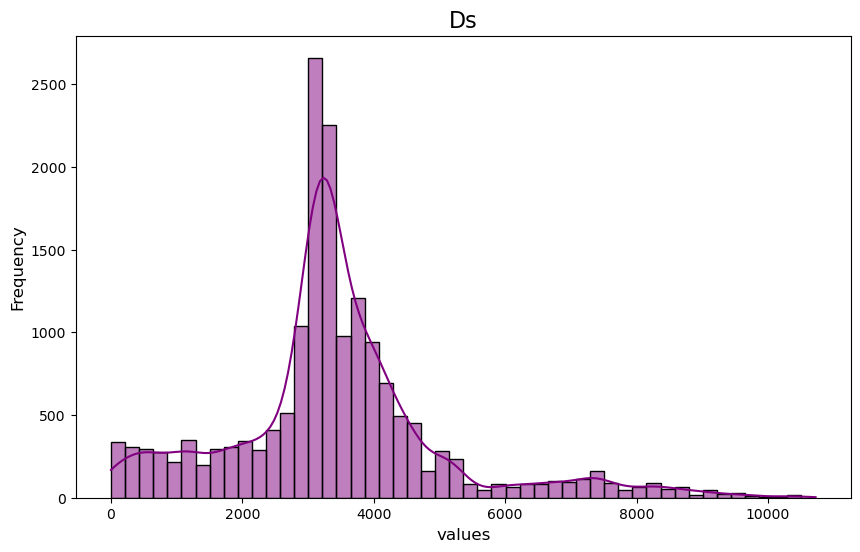

In [1]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import seaborn as sns
import functions as f


df = pd.read_csv('student_data.csv')
print("the size of the dataset is:", np.size(df))
df.head()
print("amount of columns:", df.columns.size)
print("amount of null values in the dataset:", df.isna().sum().sum())
print("columns with null values:", df.columns[df.isna().any()])
print("null values per column:")
print(df.isna().sum(axis=0))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()
column = 'Ds'
f.eda_info(df[column],column)

columns:  86
columns:  86


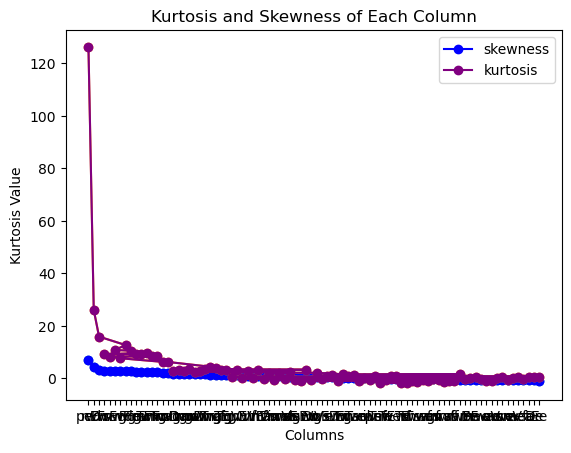

In [2]:
kurtosis = df.kurtosis(axis=0)
skewness = df.skew(axis=0)
sk_sort, ku_sort = f.sort_values(skewness, kurtosis)
sk_text = ['Columns', 'Skewness Value', 'Skewness of Each Column', 'skewness']
ku_text = ['Columns', 'Kurtosis Value', 'Kurtosis and Skewness of Each Column', 'kurtosis']
f.plot_values(sk_sort.index, sk_sort.values, sk_text)
f.plot_values(ku_sort.index, ku_sort.values, ku_text, color_used='purple')
#f.total_eda_info(df)


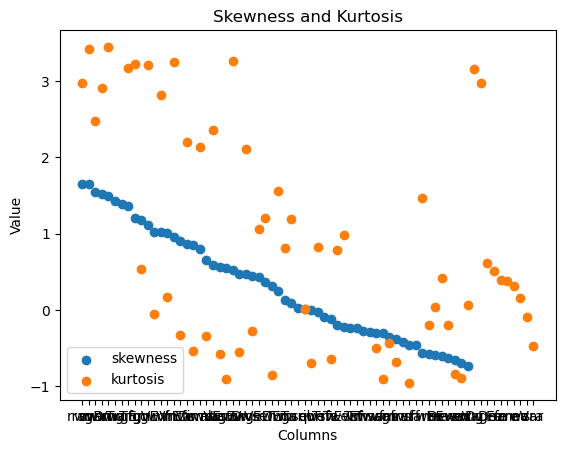

columns:  60


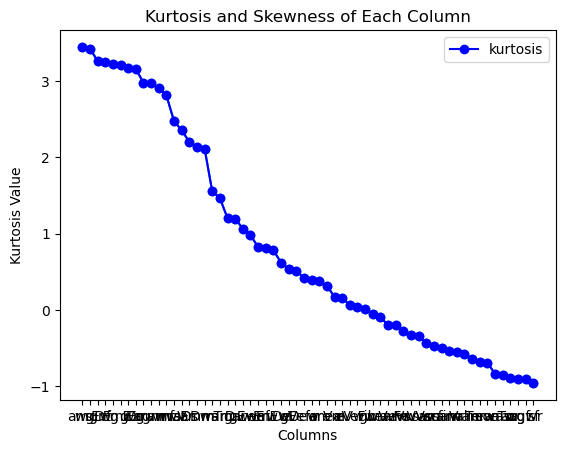

In [3]:
condition = (ku_sort > -1) & (ku_sort < 4)
plt.scatter(sk_sort.index[condition], sk_sort.values[condition], marker='o', label='skewness')
plt.scatter(ku_sort.index[condition], ku_sort.values[condition], marker='o', label='kurtosis')
plt.xlabel('Columns')
plt.ylabel('Value')
plt.title('Skewness and Kurtosis')
plt.legend()
plt.show()
f.plot_values(ku_sort.index[condition], ku_sort.values[condition], ku_text)


Classifying with kurtosis and skewness 

In [4]:

meso_kt, lepto_kt, platy_kt = f.classify_kurtosis(ku_sort,epsilon=0.1)


Mesokurtic columns:
 5 columns
Leptokurtic columns:
 53 columns
Platykurtic columns:
 28 columns


In [5]:
epsilon = 0.1
print("Meso-Kurtosis Columns skewness:")
left_sk_meso, middle_sk_meso, right_sk_meso = f.classify_skewness(meso_kt, epsilon)
print(" ")
print("Lepto-Kurtosis Columns skewness:")
left_sk_lepto, middle_sk_lepto, right_sk_lepto = f.classify_skewness(lepto_kt, epsilon)
print(" ")
print("Platy-Kurtosis Columns skewness:")
left_sk_platy, middle_sk_platy, right_sk_platy = f.classify_skewness(platy_kt, epsilon)

Meso-Kurtosis Columns skewness:
Left-skewed columns:
 5 columns
Right-skewed columns:
 5 columns
Approximately symmetric columns:
 5 columns
 
Lepto-Kurtosis Columns skewness:
Left-skewed columns:
 53 columns
Right-skewed columns:
 53 columns
Approximately symmetric columns:
 53 columns
 
Platy-Kurtosis Columns skewness:
Left-skewed columns:
 28 columns
Right-skewed columns:
 28 columns
Approximately symmetric columns:
 28 columns


* platy_kurtosis(Mean or min/max) is left skewed wich means we can use the median
* lepto_kurtosis(Median) is Right skewed wich means we can use the median
* Meso_kurtosis(Mean) is symmetric wich means we can use the mean


In [6]:
print("Meso-Kurtosis Columns:")
print(meso_kt)




Meso-Kurtosis Columns:
             0
eVw   0.065858
eF    0.036338
ril   0.008819
gwV  -0.054869
wear -0.094710


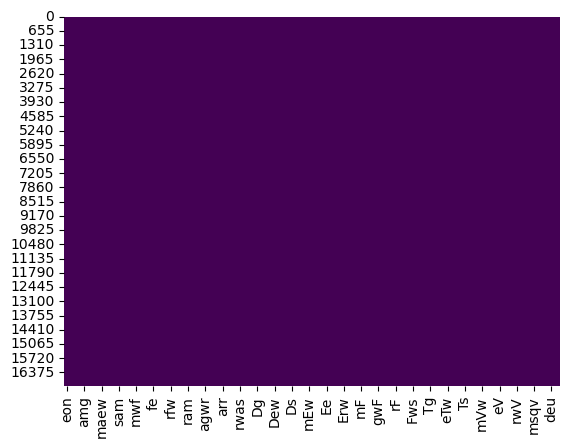

columns:  86
columns:  86


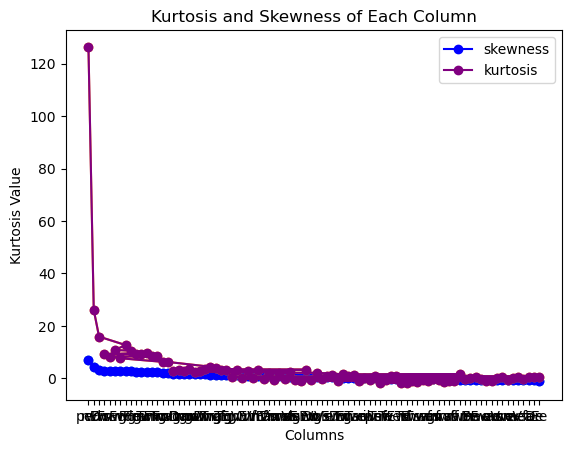

In [ ]:
dvalues = df.copy()
dvalues = f.mean_imputation(dvalues, meso_kt.index)
dvalues = f.median_imputation(dvalues, lepto_kt.index)
dvalues = f.mean_imputation(dvalues, platy_kt.index)
dvalues.isna().sum()
sns.heatmap(dvalues.isnull(), cbar=False, cmap='viridis')
plt.show()
dkurtosis = dvalues.kurtosis(axis=0)
dskewness = dvalues.skew(axis=0)
dsk_sort, dku_sort = f.sort_values(dskewness, dkurtosis)
sk_text = ['Columns', 'Skewness Value', 'Skewness of Each Column after imputation', 'skewness']
ku_text = ['Columns', 'Kurtosis Value', 'Kurtosis and Skewness of Each Column after imputation', 'kurtosis']
f.plot_values(dsk_sort.index, dsk_sort.values, sk_text)
f.plot_values(dku_sort.index, dku_sort.values, ku_text, color_used='purple')

# Part 2: Conceptual Questions & Model Selection

**Answer the following questions below:**
1. Why is this specific problem framed as a **Regression** task?
2. If a colleague suggested using **Logistic Regression** for this task, how would you explain to them mathematically and conceptually why that is the wrong choice?

# Part 3: Linear Regression & Regularization
1. **Unregularized Linear Regression:** Train a standard Ordinary Least Squares (OLS) Linear Regression model. Record its performance (RMSE, MAE, and $R^2$) on your local test set.
2. Analyze the fullfilment of the linear regression model assumptions. 
3. **Regularization (Ridge & Lasso):** 
   * Train a Ridge (L2) and a Lasso (L1) regression model. 
   * Use $k$-fold cross-validation to find the optimal regularization hyperparameters ($\alpha$).
4. **Reflection:** Print the top 5 largest coefficients from your unregularized model and your Ridge model. How drastically did they change? 
5. **Feature Selection:** Did your Lasso model drop any features (set their coefficients to exactly zero)? Look specifically at `lattice_refraction_index` and `mean_quantum_spin_variance`. What does their coefficient in the Lasso model tell you about their physical relevance to superconductivity?
6. **Include your best linear model weights in the submission using `joblib`**

# Part 4: Neural Networks
1. **Build a Neural Network:** Implement a feedforward Neural Network (Multi-Layer Perceptron) using `sklearn`, `PyTorch`, or `Keras`.
2. **Cross-Validation/Tuning:** Experiment with the architecture (number of hidden layers, neurons) and learning rate. Use a validation set to prevent overfitting (Early Stopping is highly recommended).
3. **Evaluation:** Evaluate your best Neural Network on your local test set using the same metrics as the linear models (RMSE, MAE, $R^2$). 
4. **Reflection:** Plot the residuals (predicted vs. true values) for both your best Linear model and your Neural Network. In what range does the linear model struggle the most compared to the NN?
5. **Include your best nn weights in the submission using `joblib`**. Describe the arquitecture.

# Part 5: Final Analysis and Exporting Predictions

**Final Analysis:**
Which model performed the best on your local test set? If a physicist asked you *which features* are most important for discovering a new material with this data, which model would you show them and why? Explain the trade-off between interpretability and performance in this context.

**Generate Final Predictions:**
Use your **best overall model** to predict the critical temperatures for the materials in `evaluation_features.csv`. Export your predictions to a CSV file named `my_predictions.csv`. It is just one column. Call it `predicted_cfinal`. 

# Bonus
If you first perform PCA, can you accomplish any dimensionality reduction? are your predictions better? analyze and support your claims.  